# **Assessment 12: Introduction to NLP & Text Preprocessing**
##### University of Santo Tomas
##### DSA4155: Artificial Intelligence
**Submitted by:** Ulrik Gabriyel C. Favorada, Sam Dominique M. Punzalan, Thom Daniel C. Yutuc

## **Abstract**
This study applies **unsupervised and supervised natural language processing techniques** to **2,000 IMDB movie reviews** sampled from a **balanced 50,000-entry dataset**. Reviews were preprocessed through **HTML removal, punctuation stripping, stop word filtering with domain-specific exclusions, and WordNet lemmatization**, then vectorized into a **normalized TF-IDF matrix of 2,000 features**. **K-Means clustering** and **Latent Dirichlet Allocation (LDA)** were applied to uncover **latent structure** in the corpus **without using sentiment labels**.

Results show that **neither method recovers sentiment effectively**, **silhouette scores remained near zero** across all values of **K**, and **LDA topics captured genre and stylistic themes rather than affective polarity**. Cross-evaluation using **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** confirmed **low alignment between discovered structure and true sentiment labels**. These findings indicate that **sentiment is a supervisory signal orthogonal to the thematic and stylistic patterns that unsupervised methods naturally surface**.

**Logistic Regression** on the **TF-IDF representation** is proposed as a **supervised extension**, leveraging the same feature matrix with **binary sentiment labels** to directly model the relationship between **vocabulary and review polarity**.


## **0 - Libraries and Modules**

In [87]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import spacy

# nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [88]:
# Download required resources (run once)
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Thom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Thom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Thom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## **1 - Data Loading & Exploration**

Load IMDB Dataset.csv. Print the shape and first 3 rows.

In [116]:
# Load Dataset
df = pd.read_csv("IMDB Dataset.csv")
print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive


Print the sentiment distribution using value_counts(). Confirm the dataset is balanced.

In [118]:
# Print sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:\n")
print(sentiment_counts)

# Confirm if balanced
if sentiment_counts.nunique() == 1:
    print("\nThe dataset is balanced.")
else:
    print("\nThe dataset is not balanced.")


Sentiment Distribution:

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

The dataset is balanced.


Compute the average word count per review for each sentiment group. Which group tends to write longer reviews?

In [117]:
avg_word_count = df.groupby("sentiment")["review"].apply(
    lambda x: x.str.split().apply(len).mean()
)

print(avg_word_count)
print("\nThe group with positive sentiments write longer reviews")

sentiment
negative    229.46456
positive    232.84932
Name: review, dtype: float64

The group with positive sentiments write longer reviews


**Print 2 sample reviews for each sentiment. Do they read like what you would expect from a movie review?**

In [120]:
# Show full text
pd.set_option("display.max_colwidth", None)

# Print 2 full reviews for each sentiment
for sentiment in df["sentiment"].unique():
    print(f"\n--- {sentiment.upper()} REVIEWS ---\n")
    
    reviews = df[df["sentiment"] == sentiment]["review"].head(2)
    
    for i, review in enumerate(reviews, 1):
        print(f"Review {i}:\n{review}\n")
        print("-" * 100)


--- POSITIVE REVIEWS ---

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main

> Yes it reads like a normal movie review I would see though a bit lengthier.

## **2 - Text Cleaning & Tokenization**

**Write a clean_text(text) function that: (a) lowercases, (b) removes HTML tags using re — this dataset contains <br /> tags, (c) removes punctuation and numbers, (d) strips extra whitespace. Apply it to the review column and store in a cleaned column.**

In [124]:
# Cleaning function
def clean_text(text):
    text = text.lower()                    # lowercase
    text = re.sub(r"<.*?>", "", text)      # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)   # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text)       # remove extra whitespace
    return text.strip()

# Apply cleaning
df["cleaned"] = df["review"].apply(clean_text)

# Show sample
print(df[["review", "cleaned"]].head(1))

**Tokenize the cleaned column using nltk.word_tokenize. Remove English stop words. Store the result in a tokens column.**

In [125]:
# Stop words set
stop_words = set(stopwords.words("english"))

# Tokenize + remove stopwords
df["tokens"] = df["cleaned"].apply(
    lambda text: [word for word in word_tokenize(text) if word not in stop_words]
)

# Show sample
print(df[["cleaned", "tokens"]].head(1))

**Print the 20 most frequent tokens overall. Do any tokens seem too generic for sentiment analysis (e.g., film, movie, one)? Add at least 3 to a custom stop word list and re-filter.**

In [126]:
# flatten tokens
all_tokens = [token for sublist in df["tokens"] for token in sublist]

# frequency count
freq = Counter(all_tokens)

# convert to DataFrame
top20 = pd.DataFrame(freq.most_common(20), columns=["token", "frequency"])

print(top20)

     token  frequency
0    movie      83578
1     film      74514
2      one      50392
3     like      38834
4     good      28502
5     even      24285
6    would      24001
7     time      23299
8   really      22900
9      see      22437
10   story      22062
11    much      18897
12    well      18463
13     get      18184
14   great      17723
15     bad      17673
16    also      17491
17  people      17486
18   first      16839
19    dont      16635


In [128]:
stop_words = set(stopwords.words("english"))

# add custom generic words
custom_stopwords = {"movie", "film", "one", "like", "even", "would", "time"}
stop_words = stop_words.union(custom_stopwords)

# re-filter tokens
df["tokens_refined"] = df["clea ned"].apply(
    lambda text: [w for w in text.split() if w not in stop_words]
)

# recompute frequency
all_tokens_refined = [t for sub in df["tokens_refined"] for t in sub]
freq_refined = Counter(all_tokens_refined)

print("Top 20 tokens after refinement:")
print(freq_refined.most_common(20))

Top 20 tokens after refinement:
[('good', 28502), ('really', 22900), ('see', 22437), ('story', 22062), ('much', 18897), ('well', 18463), ('get', 18184), ('great', 17723), ('bad', 17673), ('also', 17491), ('people', 17486), ('first', 16839), ('dont', 16635), ('movies', 15447), ('made', 15414), ('films', 15295), ('make', 15284), ('could', 15143), ('way', 15017), ('characters', 14658)]


> For sentiment analysis, "movie", "film", "still" are too generic. 

Show a before-and-after table for 3 reviews: original review → cleaned → final tokens.

In [129]:
sample = df[["review", "cleaned", "tokens"]].head(3).copy()

# convert tokens list → readable string (limit to first 20 tokens)
sample["tokens"] = sample["tokens"].apply(lambda x: ", ".join(x[:20]))

for i, row in sample.iterrows():
    print("\n" + "="*100)
    print(f"REVIEW {i+1}")
    print("="*100)

    print("\nORIGINAL REVIEW:\n")
    print(row["review"])

    print("\nCLEANED REVIEW:\n")
    print(row["cleaned"])

    print("\nTOKENS (first 20):\n")
    print(row["tokens"])
    print("\n")


REVIEW 1

ORIGINAL REVIEW:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal 

## **3 - Stemming vs. Lemmatization**

**Take a random sample of 300 reviews (random_state=42). Apply Porter Stemming to the tokens. Store in a stemmed column.**

In [98]:
# ensure reproducibility
df_sample = df.sample(n=300, random_state=42).reset_index(drop=True).copy()

# stemmer
stemmer = PorterStemmer()

# apply stemming to tokens
df_sample["stemmed"] = df_sample["tokens"].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

# preview
print(df_sample[["tokens", "stemmed"]].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          tokens  \
0                                                                                             [really, liked, summerslam, due, look, arena, curtains, look, overall,

**Apply spaCy Lemmatization to the same sample. Store in a lemmatized column.**

In [99]:
nlp = spacy.load("en_core_web_sm")

def lemmatize_tokens(tokens):
    doc = nlp(" ".join(tokens))  # convert list -> string for spaCy
    return [token.lemma_ for token in doc]

df_sample["lemmatized"] = df_sample["tokens"].apply(lemmatize_tokens)

# preview
print(df_sample[["tokens", "stemmed", "lemmatized"]].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          tokens  \
0                                                                                             [really, liked, summerslam, due, look, arena, curtains, look, overall,

**Build a comparison table of at least 10 words where stemming and lemmatization produce different outputs:**

In [100]:
# load tools
stemmer = PorterStemmer()
nlp = spacy.load("en_core_web_sm")

# flatten all tokens from your dataset sample
words = [w for sub in df_sample["tokens"] for w in sub]

results = []

for w in words:
    stem = stemmer.stem(w)
    lemma = nlp(w)[0].lemma_
    
    if stem != lemma:
        results.append((w, stem, lemma))

# remove duplicates
comparison_df = pd.DataFrame(results, columns=["Word", "Stemmed", "Lemmatized"]).drop_duplicates()

# show top 10 differences
print(comparison_df.head(10))

          Word   Stemmed   Lemmatized
0       really    realli       really
1      overall    overal      overall
2  interesting  interest  interesting
3      anyways    anyway      anyways
4         best      best         well
5        didnt     didnt           do
6           im        im            I
7      changed     chang       change
8     terrible   terribl     terrible
9        every     everi        every


**Movie reviews use strong evaluative language — words like "amazing", "terrible", "worst", "loved". Does stemming or lemmatization preserve these sentiment-carrying words better? Explain in 2–3 sentences.**

> Lemmatization preserves sentiment-carrying words better because it keeps the correct dictionary word close if not similar to the original word. Stemming can distort words, which may weaken or obscure sentiment signals. As a result, lemmatization is generally more reliable for sentiment analysis since evaluative words remain clearer and more consistent.

## **4 - TF-IDF Vectorization & Top Terms per Sentiment**

**Using your 300-review sample, apply `clean_text()` and join the filtered tokens back into strings. Build a TF-IDF matrix using `TfidfVectorizer(max_features=500, ngram_range=(1,2))`. Print the matrix shape.**

In [101]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# apply cleaning
df_sample["cleaned"] = df_sample["review"].apply(clean_text)

# if tokens already exist, we rejoin them
df_sample["processed_text"] = df_sample["tokens"].apply(lambda x: " ".join(x))

In [130]:
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(df_sample["processed_text"])

print("\nTF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (300, 500)


**For each sentiment label (positive, negative), print the top 10 TF-IDF terms by averaging TF-IDF scores across all documents in that group.**

In [103]:
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# attach sentiment labels
tfidf_df["sentiment"] = df_sample["sentiment"].values

In [131]:
for sentiment in ["positive", "negative"]:
    group = tfidf_df[tfidf_df["sentiment"] == sentiment].drop(columns=["sentiment"])
    
    mean_scores = group.mean().sort_values(ascending=False)
    
    print(f"\nTop 10 TF-IDF terms for {sentiment.upper()}:\n")
    print(mean_scores.head(10))


Top 10 TF-IDF terms for POSITIVE:

film     0.092250
movie    0.075297
one      0.061235
like     0.040795
also     0.040515
great    0.040255
best     0.038556
well     0.038301
show     0.036175
good     0.035893
dtype: float64

Top 10 TF-IDF terms for NEGATIVE:

movie    0.113768
film     0.070529
like     0.052617
bad      0.052533
one      0.051050
even     0.048808
would    0.044479
good     0.040395
made     0.038160
much     0.036741
dtype: float64


In [138]:
bigrams = [f for f in feature_names if " " in f]

# compute top bigrams per sentiment 
for sentiment in ["positive", "negative"]:
    group = tfidf_df[tfidf_df["sentiment"] == sentiment]
    
    # average TF-IDF score per bigram
    scores = group[bigrams].mean().sort_values(ascending=False)
    
    print("\n" + "="*60)
    print(f"                TOP 10 BIGRAMS FOR {sentiment.upper()}")
    print("="*60 + "\n")
    
    print(scores.head(10))


                TOP 10 BIGRAMS FOR POSITIVE

new york     0.011855
one best     0.010289
ever seen    0.005136
dtype: float64

                TOP 10 BIGRAMS FOR NEGATIVE

ever seen    0.014960
new york     0.001918
one best     0.001740
dtype: float64


**Identify at least one bigram in the top terms per sentiment and explain why it captures meaning better than its individual words alone (e.g., "special effects" vs. "special" and "effects" separately).**

> A bigram from the positive sentiment top terms is “one best”, which captures a strong evaluative phrase meaning something is among the best experiences, while “one” and “best” separately are too vague. From the negative sentiment, a bigram like “ever seen” captures a complete evaluative pattern often used in criticism (e.g., “worst ever seen”), whereas “ever” and “seen” alone do not carry a clear sentiment.

**Do the top positive and negative terms match your intuition about what makes a good or bad movie review? Discuss briefly.**

> Yes, the results mostly match intuition because positive reviews include words like great, best, and good, while negative reviews include bad. However, many top terms like film and movie are neutral and appear in both groups, so they don’t strongly reflect sentiment.

## **5 - Document Similarity**

**Using the TF-IDF matrix from Task 4, compute the cosine similarity matrix using cosine_similarity from sklearn.**

In [106]:
# assuming tfidf_matrix is already created in Task 4
cosine_sim = cosine_similarity(tfidf_matrix)

# convert to DataFrame for readability
cosine_sim_df = pd.DataFrame(cosine_sim)

print(cosine_sim_df.shape)
print(cosine_sim_df.head())

(300, 300)
        0         1         2         3         4         5         6    \
0  1.000000  0.041196  0.035390  0.029400  0.055813  0.087038  0.132127   
1  0.041196  1.000000  0.117367  0.053751  0.111980  0.045811  0.018041   
2  0.035390  0.117367  1.000000  0.027619  0.101350  0.076663  0.096057   
3  0.029400  0.053751  0.027619  1.000000  0.000000  0.098409  0.000000   
4  0.055813  0.111980  0.101350  0.000000  1.000000  0.167537  0.104014   

        7         8         9    ...       290       291       292       293  \
0  0.073883  0.084180  0.134591  ...  0.075158  0.065651  0.052226  0.113875   
1  0.163074  0.210334  0.148913  ...  0.060132  0.131478  0.161273  0.091391   
2  0.155870  0.109596  0.195677  ...  0.087800  0.062270  0.075104  0.048215   
3  0.016839  0.060012  0.059589  ...  0.035107  0.074744  0.046760  0.013684   
4  0.178015  0.131984  0.155723  ...  0.075417  0.112809  0.081984  0.125472   

        294       295       296       297       298      

**Pick one negative review from your sample. Find its top 3 most similar reviews (excluding itself). Print each review's first 150 characters and sentiment. Are they also negative?**

In [139]:
neg_indices = df_sample[df_sample["sentiment"] == "negative"].index
target_idx = neg_indices[0]

print("\nSelected negative review:\n")
print(df_sample.loc[target_idx, "review"][:150])
print("\nSentiment:", df_sample.loc[target_idx, "sentiment"])


Selected negative review:

The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would hav

Sentiment: negative


In [108]:
similarities = cosine_sim[target_idx]

# sort indices by similarity (descending)
similar_indices = similarities.argsort()[::-1]

top_3 = []
for idx in similar_indices:
    if idx != target_idx:
        top_3.append(idx)
    if len(top_3) == 3:
        break

In [109]:
for i, idx in enumerate(top_3, 1):
    print("\n" + "="*80)
    print(f"SIMILAR REVIEW {i}")
    print("="*80)

    print("\nREVIEW TEXT:\n")
    print(df_sample.iloc[idx]["review"][:150])

    print("\nSENTIMENT:", df_sample.iloc[idx]["sentiment"])


SIMILAR REVIEW 1

REVIEW TEXT:

Sunday would not be Sunday without an action movie, and when you want intense combat, you turn to Tom Berenger (Platoon).<br /><br />Here he plays a s

SENTIMENT: positive

SIMILAR REVIEW 2

REVIEW TEXT:

OK, I wanted to see this because it had a few good reviews, but this movie was awful... Just plain awful. The characters were 1 dimensional and nothin

SENTIMENT: negative

SIMILAR REVIEW 3

REVIEW TEXT:

First of all I would like to point out that this film has absolutely nothing to see with the Dutch folklore story of the ghost ship that is also calle

SENTIMENT: negative


Pick one positive review and repeat.

In [140]:
pos_indices = df_sample[df_sample["sentiment"] == "positive"].index
target_idx = pos_indices[0]   # or np.random.choice(pos_indices) for randomness

print("\nSelected positive review:\n")
print(df_sample.iloc[target_idx]["review"][:150])
print("\nSentiment:", df_sample.iloc[target_idx]["sentiment"])


Selected positive review:

I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th

Sentiment: positive


In [111]:
similarities = cosine_sim[target_idx]

# sort by similarity (highest first)
similar_indices = similarities.argsort()[::-1]

# exclude itself + take top 3
top_3 = [i for i in similar_indices if i != target_idx][:3]

In [112]:
for i, idx in enumerate(top_3, 1):
    print("\n" + "="*80)
    print(f"SIMILAR REVIEW {i}")
    print("="*80)

    print("\nREVIEW TEXT:\n")
    print(df_sample.iloc[idx]["review"][:150])

    print("\nSENTIMENT:", df_sample.iloc[idx]["sentiment"])


SIMILAR REVIEW 1

REVIEW TEXT:

I was browsing through the movies on demand and saw Underdog for free and it was only 82 minutes long so I decided to watch it. I wasn't expecting muc

SENTIMENT: negative

SIMILAR REVIEW 2

REVIEW TEXT:

"Radio Flyer" is one of my most loved American movies.<br /><br />The really great job of two boys, Joe Mazzello and Elija Wood, (in spite of terrible

SENTIMENT: positive

SIMILAR REVIEW 3

REVIEW TEXT:

I'm just filling this comment out, because I couldn't stand the fact that a positive comment was featured on the "complete information" page. I really

SENTIMENT: negative


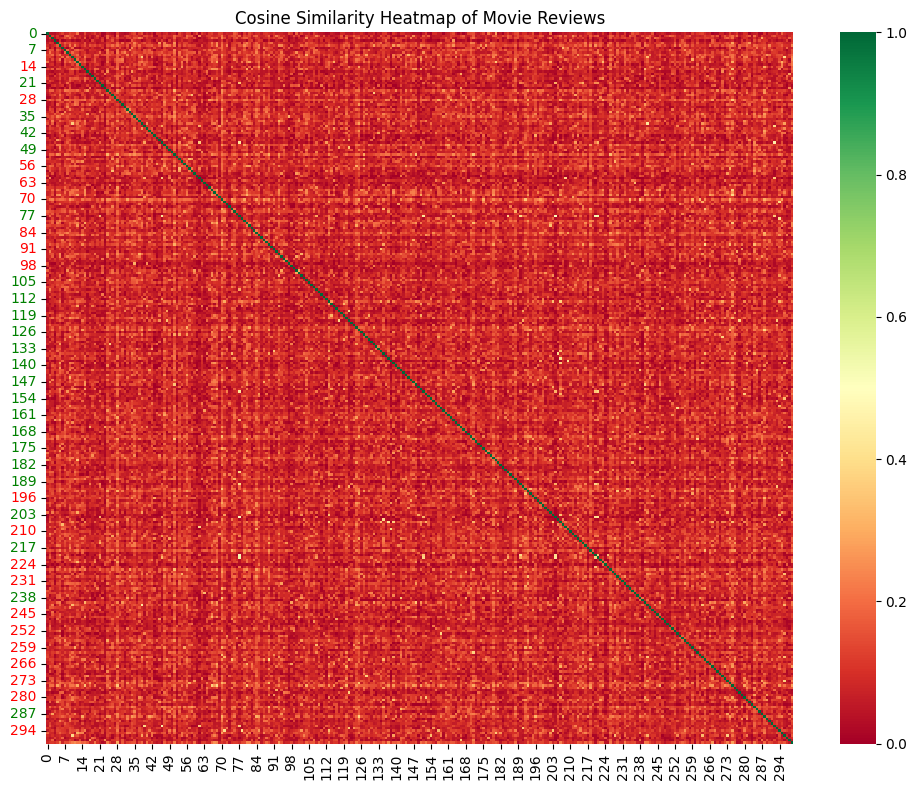

In [113]:
# -------------------------
# 1. Heatmap
# -------------------------
plt.figure(figsize=(10, 8))

sns.heatmap(
    cosine_sim,
    cmap="RdYlGn",
    annot=False
)

plt.title("Cosine Similarity Heatmap of Movie Reviews")

# -------------------------
# 2. Color y-axis labels by sentiment
# -------------------------
ax = plt.gca()

sentiments = df_sample["sentiment"].values

for i, tick in enumerate(ax.get_yticklabels()):
    if sentiments[i] == "positive":
        tick.set_color("green")
    else:
        tick.set_color("red")

plt.tight_layout()
plt.show()

In [114]:
order = np.argsort(df_sample["sentiment"].values)

sorted_sim = cosine_sim[order][:, order]

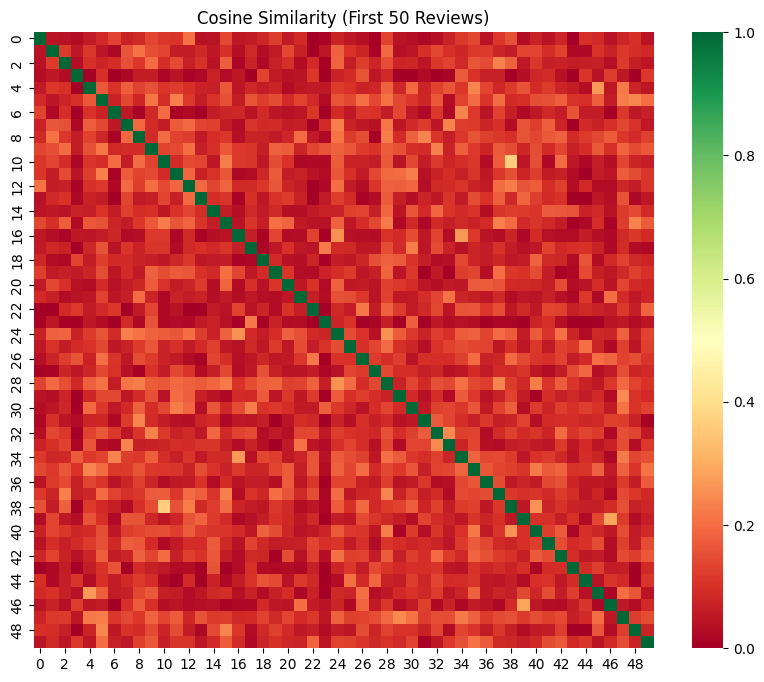

In [115]:
plt.figure(figsize=(10, 8))

sns.heatmap(cosine_sim[:50, :50], cmap="RdYlGn")

plt.title("Cosine Similarity (First 50 Reviews)")
plt.show()

## **Other Model to Use:**

**Logistic Regression (Classification Model):**
- Logistic regression is suitable because TF-IDF converts movie reviews into numerical features, and regression models are designed to learn relationships between numerical inputs and outputs.
- It learns how strongly words like *great* or *bad* influence sentiment and uses these weights to estimate the probability that a review is positive or negative.
- Although it is called a regression model, it applies a logistic (sigmoid) function to convert predictions into probabilities for binary classification.


We used ChatGPT and Claude for this assessment.